# 📊 Comprehensive Fitting Pipeline (860 cm⁻¹)

This notebook is organized to compare three different fitting methods on the 860 cm⁻¹ wavenumber data:
1. **Complex Hankel Transform (CHT)**: The $k$-space method from the 2015 Nature Materials paper.
2. **Real Space Hankel**: Fitting the spatial amplitude directly using the Hankel model.
3. **Real Space $1/\sqrt{x}$**: Fitting the spatial amplitude directly using an inverse square-root envelope.

All results are extracted and automatically logged into `data/fitting_results_comparison.csv`.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter
import scipy.special as sp
import sys
sys.path.append('.')
import nanoftir_Shizhe as nanoftir
import importlib
importlib.reload(nanoftir)
%matplotlib widget
# 🎨 APS Plotting Style Configuration
plt.rcParams.update({
    'font.size': 12, 'font.family': 'Arial',
    'axes.linewidth': 1.5, 'xtick.major.width': 1.5, 'ytick.major.width': 1.5,
    'xtick.direction': 'in', 'ytick.direction': 'in', 'xtick.top': True,
    'ytick.right': True
})

## 1. Batch Data Alignment & Initialization
Here we load all 15 wavenumbers, visualize them in an unaligned state, apply a customizable edge shift via `align_dict`, and visualize the aligned result. Once aligned, we select one target wavenumber to pass to the downstream fitting pipelines.

Saved to figures/waterfall_unaligned.png


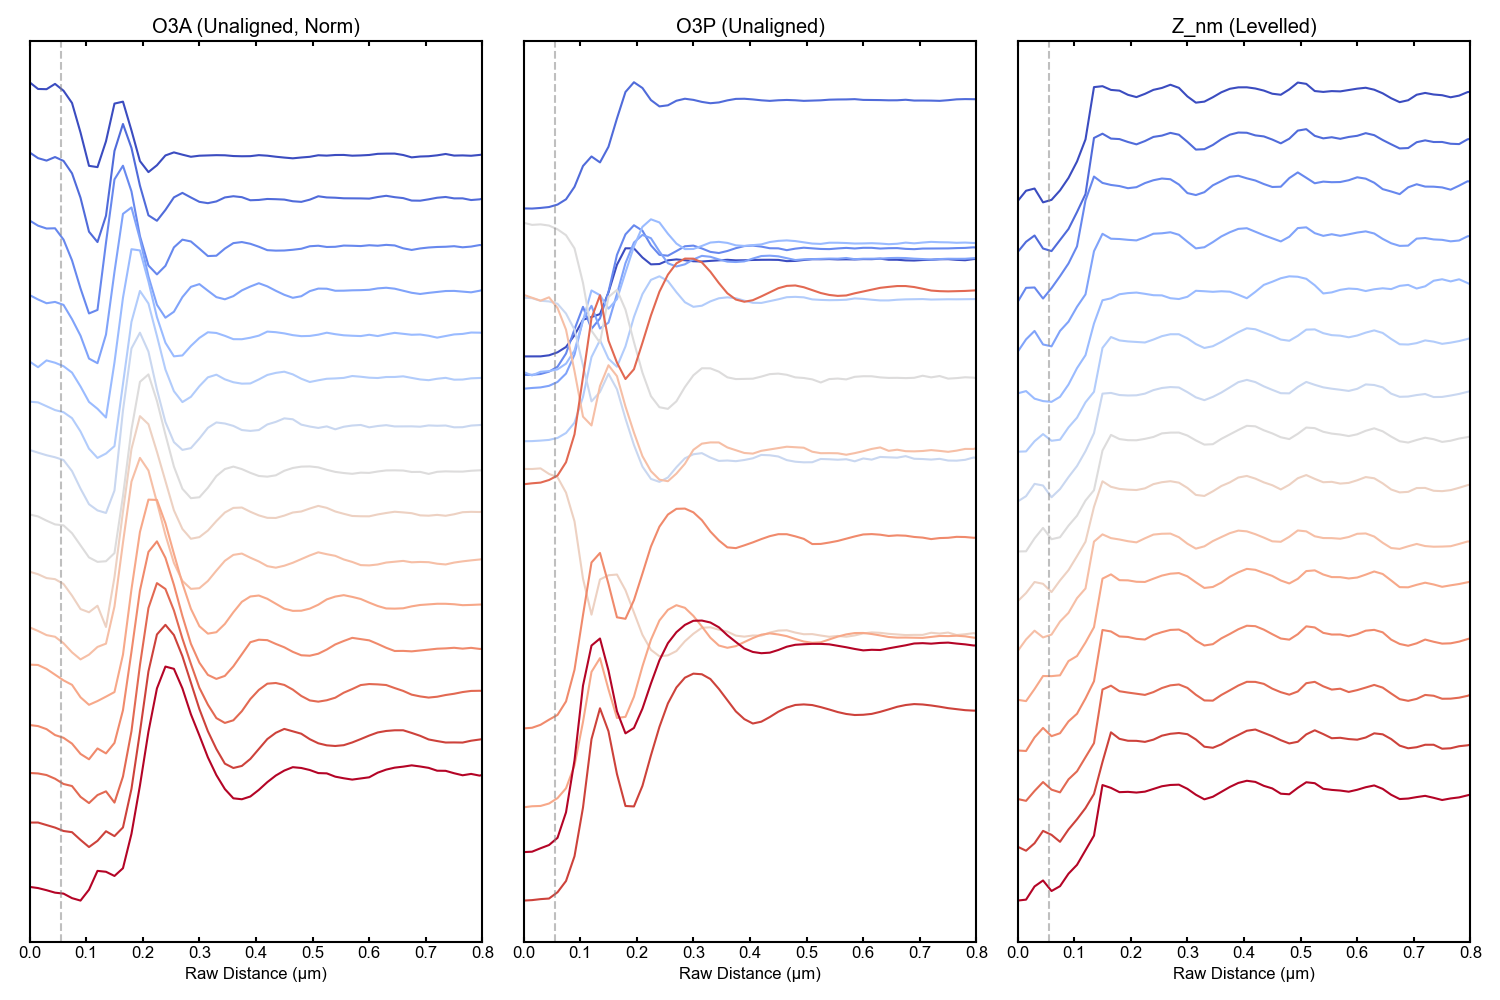

In [3]:
import glob
import re
import matplotlib.cm as cm
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

data_dir = 'data/graphene_3x1'
file_paths = glob.glob(f'{data_dir}/*_AVG_lp1.csv')

# ==========================================
# 🌟 VISUALIZATION SETTINGS (Tweak these!) 🌟
# ==========================================
normalize_A = True   # Normalize Amplitude to 1
normalize_P = False  # Normalize Phase to 1

# ⬇️ offset to set the intervals
offset_A = 0.15  
offset_P = 0.4   
offset_Z = 1.0  
# ==========================================

# Extract wavenumbers and sort
def get_wn(p):
    match = re.search(r'(\d+)cm-1', p)
    return int(match.group(1)) if match else 0

file_paths = sorted(file_paths, key=get_wn, reverse=True)
wn_list = [f"{get_wn(p)}cm-1" for p in file_paths]

# Load raw data and apply custom Z correction
raw_data_dict = {}
for wn, path in zip(wn_list, file_paths):
    df = pd.read_csv(path)
    df['Z_nm_custom'] = df['Z_nm_corrected'] - df['Z_nm_corrected'].min()
    raw_data_dict[wn] = df

# Plot 1x3 Unaligned Waterfall
fig, axs = plt.subplots(1, 3, figsize=(15, 10))
colors = cm.coolwarm(np.linspace(0, 1, len(wn_list)))

for i, wn in enumerate(wn_list):
    df = raw_data_dict[wn]
    x = df['distance_nm'] / 1000.0  # to um
    
    a_data = df['O3A']
    p_data = df['O3P']
    
    if normalize_A: a_data = a_data / a_data.max()
    if normalize_P: p_data = p_data / p_data.max()
    
    axs[0].plot(x, a_data - offset_A * i, color=colors[i], lw=1.5)
    axs[1].plot(x, p_data - offset_P * i, color=colors[i], lw=1.5)
    axs[2].plot(x, df['Z_nm_custom'] - offset_Z * i, color=colors[i], lw=1.5)

axs[0].set_title('O3A (Unaligned' + (', Norm)' if normalize_A else ')'))
axs[1].set_title('O3P (Unaligned' + (', Norm)' if normalize_P else ')'))
axs[2].set_title('Z_nm (Levelled)')

for ax in axs:
    ax.set_xlabel('Raw Distance (μm)')
    ax.set_yticks([]) # Clean waterfall look
    ax.axvline(0.055, color='gray', linestyle='--', alpha=0.5)
    ax.set_xlim(0,0.8)

plt.tight_layout()

# Save to figures folder
os.makedirs('figures', exist_ok=True)
fig.savefig('figures/waterfall_unaligned.png', dpi=300, bbox_inches='tight')
print("Saved to figures/waterfall_unaligned.png")


In [ ]:
# 🌟 Interactive Alignment Dictionary 🌟
# Modify the shift value (in nm) for any wavenumber to manually align its edge to X=0.
align_dict = {
    '860cm-1': 60,
    '870cm-1': 75,
    '880cm-1': 75,
    '890cm-1': 75,
    '900cm-1': 75,
    '911cm-1': 65,
    '920cm-1': 65,
    '930cm-1': 75,
    '941cm-1': 63,
    '950cm-1': 75,
    '960cm-1': 65,
    '970cm-1': 65,
    '980cm-1': 45,
    '991cm-1': 61,
    '1000cm-1': 55,
}

# Apply alignment
aligned_data_dict = {}
for wn in wn_list:
    df_aligned = raw_data_dict[wn].copy()
    shift_nm = align_dict[wn]
    df_aligned['distance_um'] = (df_aligned['distance_nm'] - shift_nm) / 1000.0
    aligned_data_dict[wn] = df_aligned

# Plot 1x3 Aligned Waterfall
fig, axs = plt.subplots(1, 3, figsize=(15, 10))

for i, wn in enumerate(wn_list):
    df = aligned_data_dict[wn]
    x = df['distance_um']
    
    a_data = df['O3A']
    p_data = df['O3P']
    
    if normalize_A: a_data = a_data / a_data.max()
    if normalize_P: p_data = p_data / p_data.max()
    
    axs[0].plot(x, a_data - offset_A * i, color=colors[i], lw=1.5)
    axs[1].plot(x, p_data - offset_P * i, color=colors[i], lw=1.5)
    axs[2].plot(x, df['Z_nm_custom'] - offset_Z * i, color=colors[i], lw=1.5)

axs[0].set_title('O3A (Aligned' + (', Norm)' if normalize_A else ')'))
axs[1].set_title('O3P (Aligned' + (', Norm)' if normalize_P else ')'))
axs[2].set_title('Z_nm (Levelled & Aligned)')

for ax in axs:
    ax.set_xlabel('Aligned Distance (μm)')
    ax.set_yticks([])
    ax.axvline(0.0, color='red', linestyle='--', alpha=0.8, lw=2)
    ax.set_xlim(-0.08, 1.5)

plt.tight_layout()

# Save to figures folder
fig.savefig('figures/waterfall_aligned.png', dpi=300, bbox_inches='tight')
print("Saved to figures/waterfall_aligned.png")


In [ ]:
# === Select Target Wavenumber for Downstream Fitting ===
target_wn = '860cm-1'
L_cutoff = 1.5

df_target = aligned_data_dict[target_wn]
x_mat = df_target['distance_um'].values
y_mat = df_target['O3A'].values

from scipy.signal import savgol_filter
# Background Subtraction
window_len = min(41, len(y_mat) if len(y_mat) % 2 != 0 else len(y_mat)-1)
y_bg = savgol_filter(y_mat, window_length=window_len, polyorder=2)
y_mat = y_mat - y_bg

# Phase data preparation (used by downstream FFT cell)
# Because some downstream scripts rely on pandas Series mapped directly,
# we construct amplp and phaselp dummy DataFrames to preserve compatibility
amplp = pd.DataFrame({'distance_um': x_mat, f'{target_wn}_O3A': y_mat})
phaselp = pd.DataFrame({f'{target_wn}_O3P': df_target['O3P'].values})

# Keep only positive x (on the material) up to L_cutoff for CHT/RealSpace fits
mask_fit = (x_mat >= 0) & (x_mat <= L_cutoff)
x_f = x_mat[mask_fit]
sig_f = y_mat[mask_fit]

print(f"Loaded {target_wn} for fitting. Edge aligned at x=0. Total fitting points: {len(x_f)}")


## 2. Fit 1: Complex Hankel Transform (CHT)
Here is the CHT fit. You can adjust the parameters below.
- `lam0_guess_um`: Your initial guess for the wavelength (e.g. 0.400).
- `k_fit_range`: The momentum range to fit the peak. You can try `(2, 30)` or `(4, 25)` depending on where the peak is.
- `L_cutoff`: The distance cutoff for the Hankel transform integral.

In [ ]:
# === Tunable Parameters for CHT (per-wn: adjust k_fit_range_cm / k_linked_guess_cm here) ===
x_start_cht = 0.22
L_cutoff = 1.2
k_fit_range_cm = (0.5, 5.0)
k_linked_guess_cm = 1.5
# ==============================================

cht_results, fig_cht = nanoftir.fit_and_plot_cht(
    x_f, sig_f, target_wn, x_start_cht=x_start_cht, L_cutoff_cht=L_cutoff,
    k_fit_range_cm=k_fit_range_cm, k_linked_guess_cm=k_linked_guess_cm)

print(f"Single Plasmon Mode: q_p \u2248 {cht_results['q_re']/10.0:.2f} (10^5 cm^-1)")
print(f"Wavelength = {cht_results['lambda_p_nm']:.1f} nm, Damping = {cht_results['damping']:.1f}")
fig_cht


## 3. Fit 2 & 3: Real Space Models (Hankel & $1/\sqrt{x}$)
Using your `compare_cavity_models` wrapper. I have updated `nanoftir_Shizhe.py` to natively support `edges='single'`!
This means we no longer need to hack the boundary to infinity. We just pass `edges='single'` and it correctly fits only the left boundary launched wave.

In [ ]:
# Construct DataFrame for compare_cavity_models
amplp = pd.DataFrame({
    'distance_um': x_f,
    '860cm-1_O3A': sig_f
})

# === Tunable Parameters for Real Space Fits ===
xr_range = (0.22, 1.5)   # 🌟 BUG FIXED: x_f already starts at 0, so left edge must be 0!
win_size = 3            # Window size for smoothing before peak-finding (larger = smoother)
prominence = 0.01       # Prominence for peak finding
lam0_guess_um = 0.38   # Initial guess for wavelength
# ==============================================

# Call the wrapper with natively supported single-edge mode
outs, fig, axs = nanoftir.compare_cavity_models(
    amplp, '860cm-1_O3A',
    xr=xr_range, yc_um=1.9, fit_yc=False, edges='single',
    prefactors=('hankel', '1/sqrtx'),
    win=win_size, prom=prominence, lam0_guess=lam0_guess_um,
    ylim=(sig_f.min()*2, sig_f.max()*1.5),
    figsize=(8, 6)
)
plt.show()
fig
# Display the figure in the notebook

## 4. Standard FFT Analysis (Comparison)
Let's compare the CHT momentum-space peak with a standard 1D FFT using your `plot_channel_fft` function.

In [ ]:
# === Standard 1D FFT Analysis ===
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import importlib
import nanoftir_Shizhe as nanof
importlib.reload(nanof)

try:
    print("Running standard FFT comparison...")
    # Directly use the full aligned dataframe to prevent length mismatch bugs
    x_dist = df_target['distance_um']
    amp_raw = df_target['O3A']
    phase_raw = df_target['O3P']
    
    # We subtract background here too to ensure FFT is analyzing pure oscillations
    from scipy.signal import savgol_filter
    window_len = min(41, len(amp_raw) if len(amp_raw) % 2 != 0 else len(amp_raw)-1)
    amp_bg = savgol_filter(amp_raw, window_length=window_len, polyorder=2)
    amp_osc = amp_raw - amp_bg
    
    # 🌟 q_guess is exposed here! Adjust [5, 30] to search for peaks in different k regions.
    nanof.plot_channel_fft(
        x_dist, amp_osc, phase_raw, 
        label='O3', wn=target_wn,
        xr=(0.22, 1.2), q_range=(0, 10),
        window='hann', pad_factor=3.0,
        q_guess=[1.5,3] 
    )
except Exception as e:
    import traceback
    print(f"Error running FFT: {e}")
    traceback.print_exc()


## 5. Overview: Amp / Phase / AFM Topography (860 cm⁻¹)

In [ ]:
import sys
sys.path.append('/Users/shizhe/envsetting')
import snippet

x = df_target['distance_um']
amp = df_target['O3A']
phase = df_target['O3P']
z_nm = df_target['Z_nm_custom'] - df_target['Z_nm_custom'].min()  # AFM right axis aligned to 0

fig, ax = snippet.subplots(1, 1, size=(8, 5))
ax2 = ax.twinx()

l1, = ax.plot(x, amp, color='#1c7293', lw=1.8, label='Amp')
l2, = ax.plot(x, phase, color='#b2182b', lw=1.8, label='Phase')
l3, = ax2.plot(x, z_nm, color='#555555', lw=1.5, linestyle='--', label='Z (AFM)')

ax.set_xlabel(r'Distance ($\mu$m)', fontweight='bold')
ax.set_ylabel('Amp / Phase (a.u.)', fontweight='bold')
ax2.set_ylabel('Z (nm)', fontweight='bold')
ax.tick_params(direction='in', top=True)
ax2.tick_params(direction='in')
ax.set_title('860cm-1: Amp, Phase, and AFM Topography', fontweight='bold')

lines = [l1, l2, l3]
ax.legend(lines, [l.get_label() for l in lines], frameon=False, fontsize=12, loc='upper right')

import os
os.makedirs('figures/overview', exist_ok=True)
fig.savefig('figures/overview/860cm-1_amp_phase_z.png', dpi=200, bbox_inches='tight')
fig


# ======================
# Target WN: 870cm-1
# ======================

In [ ]:
# === Select Target Wavenumber for Downstream Fitting ===
target_wn = '870cm-1'
L_cutoff = 1.5

df_target = aligned_data_dict[target_wn]
x_mat = df_target['distance_um'].values
y_mat = df_target['O3A'].values

from scipy.signal import savgol_filter
# Background Subtraction
window_len = min(41, len(y_mat) if len(y_mat) % 2 != 0 else len(y_mat)-1)
y_bg = savgol_filter(y_mat, window_length=window_len, polyorder=2)
y_mat = y_mat - y_bg

# Phase data preparation
amplp = pd.DataFrame({'distance_um': x_mat, f'{target_wn}_O3A': y_mat})
phaselp = pd.DataFrame({f'{target_wn}_O3P': df_target['O3P'].values})

# Keep only positive x (on the material) up to L_cutoff for CHT/RealSpace fits
mask_fit = (x_mat >= 0) & (x_mat <= L_cutoff)
x_f = x_mat[mask_fit]
sig_f = y_mat[mask_fit]

print(f"Loaded {target_wn} for fitting. Edge aligned at x=0. Total fitting points: {len(x_f)}")


## 1. Fit 1: Complex Hankel Transform (CHT)

In [ ]:
# === Tunable Parameters for CHT (per-wn: adjust k_fit_range_cm / k_linked_guess_cm here) ===
x_start_cht = 0.22
L_cutoff = 1.2
k_fit_range_cm = (0.5, 6.0)
k_linked_guess_cm = 1.70
# ==============================================

cht_results, fig_cht = nanoftir.fit_and_plot_cht(
    x_f, sig_f, target_wn, x_start_cht=x_start_cht, L_cutoff_cht=L_cutoff,
    k_fit_range_cm=k_fit_range_cm, k_linked_guess_cm=k_linked_guess_cm)

print(f"Single Plasmon Mode: q_p \u2248 {cht_results['q_re']/10.0:.2f} (10^5 cm^-1)")
print(f"Wavelength = {cht_results['lambda_p_nm']:.1f} nm, Damping = {cht_results['damping']:.1f}")
fig_cht


## 2. Fit 2 & 3: Real Space Models (Hankel & $1/\sqrt{x}$)

In [ ]:
# Construct DataFrame for compare_cavity_models
amplp = pd.DataFrame({
    'distance_um': x_f,
    f'{target_wn}_O3A': sig_f
})

# === Tunable Parameters for Real Space Fits ===
xr_range = (0.22, 1.5)   
win_size = 3            
prominence = 0.01       
lam0_guess_um = 0.393   
# ==============================================

outs, fig, axs = nanoftir.compare_cavity_models(
    amplp, f'{target_wn}_O3A',
    xr=xr_range, yc_um=1.9, fit_yc=False, edges='single',
    prefactors=('hankel', '1/sqrtx'),
    win=win_size, prom=prominence, lam0_guess=lam0_guess_um,
    ylim=(sig_f.min()*2, sig_f.max()*1.5),
    figsize=(8, 6)
)
plt.show()
fig


## 3. Standard FFT Analysis

In [ ]:
# === Standard 1D FFT Analysis ===
import nanoftir_Shizhe as nanof

try:
    x_dist = df_target['distance_um']
    amp_raw = df_target['O3A']
    phase_raw = df_target['O3P']
    
    from scipy.signal import savgol_filter
    window_len = min(41, len(amp_raw) if len(amp_raw) % 2 != 0 else len(amp_raw)-1)
    amp_bg = savgol_filter(amp_raw, window_length=window_len, polyorder=2)
    amp_osc = amp_raw - amp_bg
    
    nanof.plot_channel_fft(
        x_dist, amp_osc, phase_raw, 
        label='O3', wn=target_wn,
        xr=(0.22, 1.2), q_range=(0, 10),
        window='hann', pad_factor=3.0,
        q_guess=[1.6, 3.20] 
    )
except Exception as e:
    import traceback
    print(f"Error running FFT: {e}")


# ======================
# Target WN: 880cm-1
# ======================

In [ ]:
# === Select Target Wavenumber for Downstream Fitting ===
target_wn = '880cm-1'
L_cutoff = 1.5

df_target = aligned_data_dict[target_wn]
x_mat = df_target['distance_um'].values
y_mat = df_target['O3A'].values

from scipy.signal import savgol_filter
# Background Subtraction
window_len = min(41, len(y_mat) if len(y_mat) % 2 != 0 else len(y_mat)-1)
y_bg = savgol_filter(y_mat, window_length=window_len, polyorder=2)
y_mat = y_mat - y_bg

# Phase data preparation
amplp = pd.DataFrame({'distance_um': x_mat, f'{target_wn}_O3A': y_mat})
phaselp = pd.DataFrame({f'{target_wn}_O3P': df_target['O3P'].values})

# Keep only positive x (on the material) up to L_cutoff for CHT/RealSpace fits
mask_fit = (x_mat >= 0) & (x_mat <= L_cutoff)
x_f = x_mat[mask_fit]
sig_f = y_mat[mask_fit]

print(f"Loaded {target_wn} for fitting. Edge aligned at x=0. Total fitting points: {len(x_f)}")


## 1. Fit 1: Complex Hankel Transform (CHT)

In [ ]:
# === Tunable Parameters for CHT (per-wn: adjust k_fit_range_cm / k_linked_guess_cm here) ===
x_start_cht = 0.22
L_cutoff = 1.2
k_fit_range_cm = (0.5, 6.0)
k_linked_guess_cm = 1.8
# ==============================================

cht_results, fig_cht = nanoftir.fit_and_plot_cht(
    x_f, sig_f, target_wn, x_start_cht=x_start_cht, L_cutoff_cht=L_cutoff,
    k_fit_range_cm=k_fit_range_cm, k_linked_guess_cm=k_linked_guess_cm)

print(f"Single Plasmon Mode: q_p \u2248 {cht_results['q_re']/10.0:.2f} (10^5 cm^-1)")
print(f"Wavelength = {cht_results['lambda_p_nm']:.1f} nm, Damping = {cht_results['damping']:.1f}")
fig_cht


## 2. Fit 2 & 3: Real Space Models (Hankel & $1/\sqrt{x}$)

In [ ]:
# Construct DataFrame for compare_cavity_models
amplp = pd.DataFrame({
    'distance_um': x_f,
    f'{target_wn}_O3A': sig_f
})

# === Tunable Parameters for Real Space Fits ===
xr_range = (0.2, 1.5)   
win_size = 3            
prominence = 0.01       
lam0_guess_um = 0.359   
# ==============================================

outs, fig, axs = nanoftir.compare_cavity_models(
    amplp, f'{target_wn}_O3A',
    xr=xr_range, yc_um=1.9, fit_yc=False, edges='single',
    prefactors=('hankel', '1/sqrtx'),
    win=win_size, prom=prominence, lam0_guess=lam0_guess_um,
    ylim=(sig_f.min()*2, sig_f.max()*1.5),
    figsize=(8, 6)
)
plt.show()
fig


## 3. Standard FFT Analysis

In [ ]:
# === Standard 1D FFT Analysis ===
import nanoftir_Shizhe as nanof

try:
    x_dist = df_target['distance_um']
    amp_raw = df_target['O3A']
    phase_raw = df_target['O3P']
    
    from scipy.signal import savgol_filter
    window_len = min(41, len(amp_raw) if len(amp_raw) % 2 != 0 else len(amp_raw)-1)
    amp_bg = savgol_filter(amp_raw, window_length=window_len, polyorder=2)
    amp_osc = amp_raw - amp_bg
    
    nanof.plot_channel_fft(
        x_dist, amp_osc, phase_raw, 
        label='O3', wn=target_wn,
        xr=(0.22, 1.2), q_range=(0, 10),
        window='hann', pad_factor=3.0,
        q_guess=[1.7, 3.50] 
    )
except Exception as e:
    import traceback
    print(f"Error running FFT: {e}")


# ======================
# Target WN: 890cm-1
# ======================

In [ ]:
# === Select Target Wavenumber for Downstream Fitting ===
target_wn = '890cm-1'
L_cutoff = 1.5

df_target = aligned_data_dict[target_wn]
x_mat = df_target['distance_um'].values
y_mat = df_target['O3A'].values

from scipy.signal import savgol_filter
# Background Subtraction
window_len = min(41, len(y_mat) if len(y_mat) % 2 != 0 else len(y_mat)-1)
y_bg = savgol_filter(y_mat, window_length=window_len, polyorder=2)
y_mat = y_mat - y_bg

# Phase data preparation
amplp = pd.DataFrame({'distance_um': x_mat, f'{target_wn}_O3A': y_mat})
phaselp = pd.DataFrame({f'{target_wn}_O3P': df_target['O3P'].values})

# Keep only positive x (on the material) up to L_cutoff for CHT/RealSpace fits
mask_fit = (x_mat >= 0) & (x_mat <= L_cutoff)
x_f = x_mat[mask_fit]
sig_f = y_mat[mask_fit]

print(f"Loaded {target_wn} for fitting. Edge aligned at x=0. Total fitting points: {len(x_f)}")


## 1. Fit 1: Complex Hankel Transform (CHT)

In [ ]:
# === Tunable Parameters for CHT (per-wn: adjust k_fit_range_cm / k_linked_guess_cm here) ===
x_start_cht = 0.19
L_cutoff = 1.2
k_fit_range_cm = (0.5, 6.0)
k_linked_guess_cm = 1.8
# ==============================================

cht_results, fig_cht = nanoftir.fit_and_plot_cht(
    x_f, sig_f, target_wn, x_start_cht=x_start_cht, L_cutoff_cht=L_cutoff,
    k_fit_range_cm=k_fit_range_cm, k_linked_guess_cm=k_linked_guess_cm)

print(f"Single Plasmon Mode: q_p \u2248 {cht_results['q_re']/10.0:.2f} (10^5 cm^-1)")
print(f"Wavelength = {cht_results['lambda_p_nm']:.1f} nm, Damping = {cht_results['damping']:.1f}")
fig_cht


## 2. Fit 2 & 3: Real Space Models (Hankel & $1/\sqrt{x}$)

In [ ]:
# Construct DataFrame for compare_cavity_models
amplp = pd.DataFrame({
    'distance_um': x_f,
    f'{target_wn}_O3A': sig_f
})

# === Tunable Parameters for Real Space Fits ===
xr_range = (0.19, 1.5)   
win_size = 3            
prominence = 0.01       
lam0_guess_um = 0.331   
# ==============================================

outs, fig, axs = nanoftir.compare_cavity_models(
    amplp, f'{target_wn}_O3A',
    xr=xr_range, yc_um=1.9, fit_yc=False, edges='single',
    prefactors=('hankel', '1/sqrtx'),
    win=win_size, prom=prominence, lam0_guess=lam0_guess_um,
    ylim=(sig_f.min()*2, sig_f.max()*1.5),
    figsize=(8, 6)
)
plt.show()
fig


## 3. Standard FFT Analysis

In [ ]:
# === Standard 1D FFT Analysis ===
import nanoftir_Shizhe as nanof

try:
    x_dist = df_target['distance_um']
    amp_raw = df_target['O3A']
    phase_raw = df_target['O3P']
    
    from scipy.signal import savgol_filter
    window_len = min(41, len(amp_raw) if len(amp_raw) % 2 != 0 else len(amp_raw)-1)
    amp_bg = savgol_filter(amp_raw, window_length=window_len, polyorder=2)
    amp_osc = amp_raw - amp_bg
    
    nanof.plot_channel_fft(
        x_dist, amp_osc, phase_raw, 
        label='O3', wn=target_wn,
        xr=(0.19, 1.2), q_range=(0, 10),
        window='hann', pad_factor=3.0,
        q_guess=[1.8,3.80] 
    )
except Exception as e:
    import traceback
    print(f"Error running FFT: {e}")


# ======================
# Target WN: 900cm-1
# ======================

In [ ]:
# === Select Target Wavenumber for Downstream Fitting ===
target_wn = '900cm-1'
L_cutoff = 1.5

df_target = aligned_data_dict[target_wn]
x_mat = df_target['distance_um'].values
y_mat = df_target['O3A'].values

from scipy.signal import savgol_filter
# Background Subtraction
window_len = min(41, len(y_mat) if len(y_mat) % 2 != 0 else len(y_mat)-1)
y_bg = savgol_filter(y_mat, window_length=window_len, polyorder=2)
y_mat = y_mat - y_bg

# Phase data preparation
amplp = pd.DataFrame({'distance_um': x_mat, f'{target_wn}_O3A': y_mat})
phaselp = pd.DataFrame({f'{target_wn}_O3P': df_target['O3P'].values})

# Keep only positive x (on the material) up to L_cutoff for CHT/RealSpace fits
mask_fit = (x_mat >= 0) & (x_mat <= L_cutoff)
x_f = x_mat[mask_fit]
sig_f = y_mat[mask_fit]

print(f"Loaded {target_wn} for fitting. Edge aligned at x=0. Total fitting points: {len(x_f)}")


## 1. Fit 1: Complex Hankel Transform (CHT)

In [ ]:
# === Tunable Parameters for CHT (per-wn: adjust k_fit_range_cm / k_linked_guess_cm here) ===
x_start_cht = 0.19
L_cutoff = 1.2
k_fit_range_cm = (0.5, 6.0)
k_linked_guess_cm = 2
# ==============================================

cht_results, fig_cht = nanoftir.fit_and_plot_cht(
    x_f, sig_f, target_wn, x_start_cht=x_start_cht, L_cutoff_cht=L_cutoff,
    k_fit_range_cm=k_fit_range_cm, k_linked_guess_cm=k_linked_guess_cm)

print(f"Single Plasmon Mode: q_p \u2248 {cht_results['q_re']/10.0:.2f} (10^5 cm^-1)")
print(f"Wavelength = {cht_results['lambda_p_nm']:.1f} nm, Damping = {cht_results['damping']:.1f}")
fig_cht


## 2. Fit 2 & 3: Real Space Models (Hankel & $1/\sqrt{x}$)

In [ ]:
# Construct DataFrame for compare_cavity_models
amplp = pd.DataFrame({
    'distance_um': x_f,
    f'{target_wn}_O3A': sig_f
})

# === Tunable Parameters for Real Space Fits ===
xr_range = (0.19, 1.5)   
win_size = 3            
prominence = 0.01       
lam0_guess_um = 0.299   
# ==============================================

outs, fig, axs = nanoftir.compare_cavity_models(
    amplp, f'{target_wn}_O3A',
    xr=xr_range, yc_um=1.9, fit_yc=False, edges='single',
    prefactors=('hankel', '1/sqrtx'),
    win=win_size, prom=prominence, lam0_guess=lam0_guess_um,
    ylim=(sig_f.min()*2, sig_f.max()*1.5),
    figsize=(8, 6)
)
plt.show()
fig


## 3. Standard FFT Analysis

In [ ]:
# === Standard 1D FFT Analysis ===
import nanoftir_Shizhe as nanof

try:
    x_dist = df_target['distance_um']
    amp_raw = df_target['O3A']
    phase_raw = df_target['O3P']
    
    from scipy.signal import savgol_filter
    window_len = min(41, len(amp_raw) if len(amp_raw) % 2 != 0 else len(amp_raw)-1)
    amp_bg = savgol_filter(amp_raw, window_length=window_len, polyorder=2)
    amp_osc = amp_raw - amp_bg
    
    nanof.plot_channel_fft(
        x_dist, amp_osc, phase_raw, 
        label='O3', wn=target_wn,
        xr=(0.19, 1.2), q_range=(0, 10),
        window='hann', pad_factor=3.0,
        q_guess=[1.8, 3.9] 
    )
except Exception as e:
    import traceback
    print(f"Error running FFT: {e}")


# ======================
# Target WN: 911cm-1
# ======================

In [ ]:
# === Select Target Wavenumber for Downstream Fitting ===
target_wn = '911cm-1'
L_cutoff = 1.5

df_target = aligned_data_dict[target_wn]
x_mat = df_target['distance_um'].values
y_mat = df_target['O3A'].values

from scipy.signal import savgol_filter
# Background Subtraction
window_len = min(41, len(y_mat) if len(y_mat) % 2 != 0 else len(y_mat)-1)
y_bg = savgol_filter(y_mat, window_length=window_len, polyorder=2)
y_mat = y_mat - y_bg

# Phase data preparation
amplp = pd.DataFrame({'distance_um': x_mat, f'{target_wn}_O3A': y_mat})
phaselp = pd.DataFrame({f'{target_wn}_O3P': df_target['O3P'].values})

# Keep only positive x (on the material) up to L_cutoff for CHT/RealSpace fits
mask_fit = (x_mat >= 0) & (x_mat <= L_cutoff)
x_f = x_mat[mask_fit]
sig_f = y_mat[mask_fit]

print(f"Loaded {target_wn} for fitting. Edge aligned at x=0. Total fitting points: {len(x_f)}")


## 1. Fit 1: Complex Hankel Transform (CHT)

In [ ]:
# === Tunable Parameters for CHT (per-wn: adjust k_fit_range_cm / k_linked_guess_cm here) ===
x_start_cht = 0.17
L_cutoff = 1.2
k_fit_range_cm = (0.5, 7.0)
k_linked_guess_cm = 2.20
# ==============================================

cht_results, fig_cht = nanoftir.fit_and_plot_cht(
    x_f, sig_f, target_wn, x_start_cht=x_start_cht, L_cutoff_cht=L_cutoff,
    k_fit_range_cm=k_fit_range_cm, k_linked_guess_cm=k_linked_guess_cm)

print(f"Single Plasmon Mode: q_p \u2248 {cht_results['q_re']/10.0:.2f} (10^5 cm^-1)")
print(f"Wavelength = {cht_results['lambda_p_nm']:.1f} nm, Damping = {cht_results['damping']:.1f}")
fig_cht


## 2. Fit 2 & 3: Real Space Models (Hankel & $1/\sqrt{x}$)

In [ ]:
# Construct DataFrame for compare_cavity_models
amplp = pd.DataFrame({
    'distance_um': x_f,
    f'{target_wn}_O3A': sig_f
})

# === Tunable Parameters for Real Space Fits ===
xr_range = (0.17, 1.5)   
win_size = 3            
prominence = 0.01       
lam0_guess_um = 0.286   
# ==============================================

outs, fig, axs = nanoftir.compare_cavity_models(
    amplp, f'{target_wn}_O3A',
    xr=xr_range, yc_um=1.9, fit_yc=False, edges='single',
    prefactors=('hankel', '1/sqrtx'),
    win=win_size, prom=prominence, lam0_guess=lam0_guess_um,
    ylim=(sig_f.min()*2, sig_f.max()*1.5),
    figsize=(8, 6)
)
plt.show()
fig


## 3. Standard FFT Analysis

In [ ]:
# === Standard 1D FFT Analysis ===
import nanoftir_Shizhe as nanof

try:
    x_dist = df_target['distance_um']
    amp_raw = df_target['O3A']
    phase_raw = df_target['O3P']
    
    from scipy.signal import savgol_filter
    window_len = min(41, len(amp_raw) if len(amp_raw) % 2 != 0 else len(amp_raw)-1)
    amp_bg = savgol_filter(amp_raw, window_length=window_len, polyorder=2)
    amp_osc = amp_raw - amp_bg
    
    nanof.plot_channel_fft(
        x_dist, amp_osc, phase_raw, 
        label='O3', wn=target_wn,
        xr=(0.17, 1.2), q_range=(0, 10),
        window='hann', pad_factor=3.0,
        q_guess=[2, 4.0] 
    )
except Exception as e:
    import traceback
    print(f"Error running FFT: {e}")


# ======================
# Target WN: 920cm-1
# ======================

In [ ]:
# === Select Target Wavenumber for Downstream Fitting ===
target_wn = '920cm-1'
L_cutoff = 1.5

df_target = aligned_data_dict[target_wn]
x_mat = df_target['distance_um'].values
y_mat = df_target['O3A'].values

from scipy.signal import savgol_filter
# Background Subtraction
window_len = min(41, len(y_mat) if len(y_mat) % 2 != 0 else len(y_mat)-1)
y_bg = savgol_filter(y_mat, window_length=window_len, polyorder=2)
y_mat = y_mat - y_bg

# Phase data preparation
amplp = pd.DataFrame({'distance_um': x_mat, f'{target_wn}_O3A': y_mat})
phaselp = pd.DataFrame({f'{target_wn}_O3P': df_target['O3P'].values})

# Keep only positive x (on the material) up to L_cutoff for CHT/RealSpace fits
mask_fit = (x_mat >= 0) & (x_mat <= L_cutoff)
x_f = x_mat[mask_fit]
sig_f = y_mat[mask_fit]

print(f"Loaded {target_wn} for fitting. Edge aligned at x=0. Total fitting points: {len(x_f)}")


## 1. Fit 1: Complex Hankel Transform (CHT)

In [ ]:
# === Tunable Parameters for CHT (per-wn: adjust k_fit_range_cm / k_linked_guess_cm here) ===
x_start_cht = 0.16
L_cutoff = 1.2
k_fit_range_cm = (0.5, 7.0)
k_linked_guess_cm = 2.30
# ==============================================

cht_results, fig_cht = nanoftir.fit_and_plot_cht(
    x_f, sig_f, target_wn, x_start_cht=x_start_cht, L_cutoff_cht=L_cutoff,
    k_fit_range_cm=k_fit_range_cm, k_linked_guess_cm=k_linked_guess_cm)

print(f"Single Plasmon Mode: q_p \u2248 {cht_results['q_re']/10.0:.2f} (10^5 cm^-1)")
print(f"Wavelength = {cht_results['lambda_p_nm']:.1f} nm, Damping = {cht_results['damping']:.1f}")
fig_cht


## 2. Fit 2 & 3: Real Space Models (Hankel & $1/\sqrt{x}$)

In [ ]:
# Construct DataFrame for compare_cavity_models
amplp = pd.DataFrame({
    'distance_um': x_f,
    f'{target_wn}_O3A': sig_f
})

# === Tunable Parameters for Real Space Fits ===
xr_range = (0.16, 1.5)   
win_size = 3            
prominence = 0.01       
lam0_guess_um = 0.273   
# ==============================================

outs, fig, axs = nanoftir.compare_cavity_models(
    amplp, f'{target_wn}_O3A',
    xr=xr_range, yc_um=1.9, fit_yc=False, edges='single',
    prefactors=('hankel', '1/sqrtx'),
    win=win_size, prom=prominence, lam0_guess=lam0_guess_um,
    ylim=(sig_f.min()*2, sig_f.max()*1.5),
    figsize=(8, 6)
)
plt.show()
fig


## 3. Standard FFT Analysis

In [ ]:
# === Standard 1D FFT Analysis ===
import nanoftir_Shizhe as nanof

try:
    x_dist = df_target['distance_um']
    amp_raw = df_target['O3A']
    phase_raw = df_target['O3P']
    
    from scipy.signal import savgol_filter
    window_len = min(41, len(amp_raw) if len(amp_raw) % 2 != 0 else len(amp_raw)-1)
    amp_bg = savgol_filter(amp_raw, window_length=window_len, polyorder=2)
    amp_osc = amp_raw - amp_bg
    
    nanof.plot_channel_fft(
        x_dist, amp_osc, phase_raw, 
        label='O3', wn=target_wn,
        xr=(0.16, 1.2), q_range=(0, 10),
        window='hann', pad_factor=3.0,
        q_guess=[2.1,4.60] 
    )
except Exception as e:
    import traceback
    print(f"Error running FFT: {e}")


# ======================
# Target WN: 930cm-1
# ======================

In [ ]:
# === Select Target Wavenumber for Downstream Fitting ===
target_wn = '930cm-1'
L_cutoff = 1.5

df_target = aligned_data_dict[target_wn]
x_mat = df_target['distance_um'].values
y_mat = df_target['O3A'].values

from scipy.signal import savgol_filter
# Background Subtraction
window_len = min(41, len(y_mat) if len(y_mat) % 2 != 0 else len(y_mat)-1)
y_bg = savgol_filter(y_mat, window_length=window_len, polyorder=2)
y_mat = y_mat - y_bg

# Phase data preparation
amplp = pd.DataFrame({'distance_um': x_mat, f'{target_wn}_O3A': y_mat})
phaselp = pd.DataFrame({f'{target_wn}_O3P': df_target['O3P'].values})

# Keep only positive x (on the material) up to L_cutoff for CHT/RealSpace fits
mask_fit = (x_mat >= 0) & (x_mat <= L_cutoff)
x_f = x_mat[mask_fit]
sig_f = y_mat[mask_fit]

print(f"Loaded {target_wn} for fitting. Edge aligned at x=0. Total fitting points: {len(x_f)}")


## 1. Fit 1: Complex Hankel Transform (CHT)

In [ ]:
# === Tunable Parameters for CHT (per-wn: adjust k_fit_range_cm / k_linked_guess_cm here) ===
x_start_cht = 0.16
L_cutoff = 1.2
k_fit_range_cm = (0.6, 7.0)
k_linked_guess_cm = 2.2
# ==============================================

cht_results, fig_cht = nanoftir.fit_and_plot_cht(
    x_f, sig_f, target_wn, x_start_cht=x_start_cht, L_cutoff_cht=L_cutoff,
    k_fit_range_cm=k_fit_range_cm, k_linked_guess_cm=k_linked_guess_cm)

print(f"Single Plasmon Mode: q_p \u2248 {cht_results['q_re']/10.0:.2f} (10^5 cm^-1)")
print(f"Wavelength = {cht_results['lambda_p_nm']:.1f} nm, Damping = {cht_results['damping']:.1f}")
fig_cht


## 2. Fit 2 & 3: Real Space Models (Hankel & $1/\sqrt{x}$)

In [ ]:
# Construct DataFrame for compare_cavity_models
amplp = pd.DataFrame({
    'distance_um': x_f,
    f'{target_wn}_O3A': sig_f
})

# === Tunable Parameters for Real Space Fits ===
xr_range = (0.16, 1.5)   
win_size = 3            
prominence = 0.01       
lam0_guess_um = 0.267   
# ==============================================

outs, fig, axs = nanoftir.compare_cavity_models(
    amplp, f'{target_wn}_O3A',
    xr=xr_range, yc_um=1.9, fit_yc=False, edges='single',
    prefactors=('hankel', '1/sqrtx'),
    win=win_size, prom=prominence, lam0_guess=lam0_guess_um,
    ylim=(sig_f.min()*2, sig_f.max()*1.5),
    figsize=(8, 6)
)
plt.show()
fig


## 3. Standard FFT Analysis

In [ ]:
# === Standard 1D FFT Analysis ===
import nanoftir_Shizhe as nanof

try:
    x_dist = df_target['distance_um']
    amp_raw = df_target['O3A']
    phase_raw = df_target['O3P']
    
    from scipy.signal import savgol_filter
    window_len = min(41, len(amp_raw) if len(amp_raw) % 2 != 0 else len(amp_raw)-1)
    amp_bg = savgol_filter(amp_raw, window_length=window_len, polyorder=2)
    amp_osc = amp_raw - amp_bg
    
    nanof.plot_channel_fft(
        x_dist, amp_osc, phase_raw, 
        label='O3', wn=target_wn,
        xr=(0.16, 1.2), q_range=(0, 10),
        window='hann', pad_factor=3.0,
        q_guess=[2, 4.70] 
    )
except Exception as e:
    import traceback
    print(f"Error running FFT: {e}")


# ======================
# Target WN: 941cm-1
# ======================

In [ ]:
# === Select Target Wavenumber for Downstream Fitting ===
target_wn = '941cm-1'
L_cutoff = 1.5

df_target = aligned_data_dict[target_wn]
x_mat = df_target['distance_um'].values
y_mat = df_target['O3A'].values

from scipy.signal import savgol_filter
# Background Subtraction
window_len = min(41, len(y_mat) if len(y_mat) % 2 != 0 else len(y_mat)-1)
y_bg = savgol_filter(y_mat, window_length=window_len, polyorder=2)
y_mat = y_mat - y_bg

# Phase data preparation
amplp = pd.DataFrame({'distance_um': x_mat, f'{target_wn}_O3A': y_mat})
phaselp = pd.DataFrame({f'{target_wn}_O3P': df_target['O3P'].values})

# Keep only positive x (on the material) up to L_cutoff for CHT/RealSpace fits
mask_fit = (x_mat >= 0) & (x_mat <= L_cutoff)
x_f = x_mat[mask_fit]
sig_f = y_mat[mask_fit]

print(f"Loaded {target_wn} for fitting. Edge aligned at x=0. Total fitting points: {len(x_f)}")


## 1. Fit 1: Complex Hankel Transform (CHT)

In [ ]:
# === Tunable Parameters for CHT (per-wn: adjust k_fit_range_cm / k_linked_guess_cm here) ===
x_start_cht = 0.16
L_cutoff = 1.2
k_fit_range_cm = (0.5, 7.0)
k_linked_guess_cm = 2.60
# ==============================================

cht_results, fig_cht = nanoftir.fit_and_plot_cht(
    x_f, sig_f, target_wn, x_start_cht=x_start_cht, L_cutoff_cht=L_cutoff,
    k_fit_range_cm=k_fit_range_cm, k_linked_guess_cm=k_linked_guess_cm)

print(f"Single Plasmon Mode: q_p \u2248 {cht_results['q_re']/10.0:.2f} (10^5 cm^-1)")
print(f"Wavelength = {cht_results['lambda_p_nm']:.1f} nm, Damping = {cht_results['damping']:.1f}")
fig_cht


## 2. Fit 2 & 3: Real Space Models (Hankel & $1/\sqrt{x}$)

In [ ]:
# Construct DataFrame for compare_cavity_models
amplp = pd.DataFrame({
    'distance_um': x_f,
    f'{target_wn}_O3A': sig_f
})

# === Tunable Parameters for Real Space Fits ===
xr_range = (0.16, 1.5)   
win_size = 3            
prominence = 0.01       
lam0_guess_um = 0.242   
# ==============================================

outs, fig, axs = nanoftir.compare_cavity_models(
    amplp, f'{target_wn}_O3A',
    xr=xr_range, yc_um=1.9, fit_yc=False, edges='single',
    prefactors=('hankel', '1/sqrtx'),
    win=win_size, prom=prominence, lam0_guess=lam0_guess_um,
    ylim=(sig_f.min()*2, sig_f.max()*1.5),
    figsize=(8, 6)
)
plt.show()
fig


## 3. Standard FFT Analysis

In [ ]:
# === Standard 1D FFT Analysis ===
import nanoftir_Shizhe as nanof

try:
    x_dist = df_target['distance_um']
    amp_raw = df_target['O3A']
    phase_raw = df_target['O3P']
    
    from scipy.signal import savgol_filter
    window_len = min(41, len(amp_raw) if len(amp_raw) % 2 != 0 else len(amp_raw)-1)
    amp_bg = savgol_filter(amp_raw, window_length=window_len, polyorder=2)
    amp_osc = amp_raw - amp_bg
    
    nanof.plot_channel_fft(
        x_dist, amp_osc, phase_raw, 
        label='O3', wn=target_wn,
        xr=(0.16, 1.2), q_range=(0, 10),
        window='hann', pad_factor=3.0,
        q_guess=[2.5, 5.20] 
    )
except Exception as e:
    import traceback
    print(f"Error running FFT: {e}")


# ======================
# Target WN: 950cm-1
# ======================

In [ ]:
# === Select Target Wavenumber for Downstream Fitting ===
target_wn = '950cm-1'
L_cutoff = 1.5

df_target = aligned_data_dict[target_wn]
x_mat = df_target['distance_um'].values
y_mat = df_target['O3A'].values

from scipy.signal import savgol_filter
# Background Subtraction
window_len = min(41, len(y_mat) if len(y_mat) % 2 != 0 else len(y_mat)-1)
y_bg = savgol_filter(y_mat, window_length=window_len, polyorder=2)
y_mat = y_mat - y_bg

# Phase data preparation
amplp = pd.DataFrame({'distance_um': x_mat, f'{target_wn}_O3A': y_mat})
phaselp = pd.DataFrame({f'{target_wn}_O3P': df_target['O3P'].values})

# Keep only positive x (on the material) up to L_cutoff for CHT/RealSpace fits
mask_fit = (x_mat >= 0) & (x_mat <= L_cutoff)
x_f = x_mat[mask_fit]
sig_f = y_mat[mask_fit]

print(f"Loaded {target_wn} for fitting. Edge aligned at x=0. Total fitting points: {len(x_f)}")


## 1. Fit 1: Complex Hankel Transform (CHT)

In [ ]:
# === Tunable Parameters for CHT (per-wn: adjust k_fit_range_cm / k_linked_guess_cm here) ===
x_start_cht = 0.15
L_cutoff = 1.2
k_fit_range_cm = (0.8, 8.0)
k_linked_guess_cm = 2.70
# ==============================================

cht_results, fig_cht = nanoftir.fit_and_plot_cht(
    x_f, sig_f, target_wn, x_start_cht=x_start_cht, L_cutoff_cht=L_cutoff,
    k_fit_range_cm=k_fit_range_cm, k_linked_guess_cm=k_linked_guess_cm)

print(f"Single Plasmon Mode: q_p \u2248 {cht_results['q_re']/10.0:.2f} (10^5 cm^-1)")
print(f"Wavelength = {cht_results['lambda_p_nm']:.1f} nm, Damping = {cht_results['damping']:.1f}")
fig_cht


## 2. Fit 2 & 3: Real Space Models (Hankel & $1/\sqrt{x}$)

In [ ]:
# Construct DataFrame for compare_cavity_models
amplp = pd.DataFrame({
    'distance_um': x_f,
    f'{target_wn}_O3A': sig_f
})

# === Tunable Parameters for Real Space Fits ===
xr_range = (0.15, 1.5)   
win_size = 3            
prominence = 0.01       
lam0_guess_um = 0.233   
# ==============================================

outs, fig, axs = nanoftir.compare_cavity_models(
    amplp, f'{target_wn}_O3A',
    xr=xr_range, yc_um=1.9, fit_yc=False, edges='single',
    prefactors=('hankel', '1/sqrtx'),
    win=win_size, prom=prominence, lam0_guess=lam0_guess_um,
    ylim=(sig_f.min()*2, sig_f.max()*1.5),
    figsize=(8, 6)
)
plt.show()
fig


## 3. Standard FFT Analysis

In [ ]:
# === Standard 1D FFT Analysis ===
import nanoftir_Shizhe as nanof

try:
    x_dist = df_target['distance_um']
    amp_raw = df_target['O3A']
    phase_raw = df_target['O3P']
    
    from scipy.signal import savgol_filter
    window_len = min(41, len(amp_raw) if len(amp_raw) % 2 != 0 else len(amp_raw)-1)
    amp_bg = savgol_filter(amp_raw, window_length=window_len, polyorder=2)
    amp_osc = amp_raw - amp_bg
    
    nanof.plot_channel_fft(
        x_dist, amp_osc, phase_raw, 
        label='O3', wn=target_wn,
        xr=(0.15, 1.2), q_range=(0, 10),
        window='hann', pad_factor=3.0,
        q_guess=[2.5, 5.40] 
    )
except Exception as e:
    import traceback
    print(f"Error running FFT: {e}")


# ======================
# Target WN: 960cm-1
# ======================

In [ ]:
# === Select Target Wavenumber for Downstream Fitting ===
target_wn = '960cm-1'
L_cutoff = 1.5

df_target = aligned_data_dict[target_wn]
x_mat = df_target['distance_um'].values
y_mat = df_target['O3A'].values

from scipy.signal import savgol_filter
# Background Subtraction
window_len = min(41, len(y_mat) if len(y_mat) % 2 != 0 else len(y_mat)-1)
y_bg = savgol_filter(y_mat, window_length=window_len, polyorder=2)
y_mat = y_mat - y_bg

# Phase data preparation
amplp = pd.DataFrame({'distance_um': x_mat, f'{target_wn}_O3A': y_mat})
phaselp = pd.DataFrame({f'{target_wn}_O3P': df_target['O3P'].values})

# Keep only positive x (on the material) up to L_cutoff for CHT/RealSpace fits
mask_fit = (x_mat >= 0) & (x_mat <= L_cutoff)
x_f = x_mat[mask_fit]
sig_f = y_mat[mask_fit]

print(f"Loaded {target_wn} for fitting. Edge aligned at x=0. Total fitting points: {len(x_f)}")


## 1. Fit 1: Complex Hankel Transform (CHT)

In [ ]:
# === Tunable Parameters for CHT (per-wn: adjust k_fit_range_cm / k_linked_guess_cm here) ===
x_start_cht = 0.14
L_cutoff = 1.2
k_fit_range_cm = (0.5, 8.0)
k_linked_guess_cm = 3.00
# ==============================================

cht_results, fig_cht = nanoftir.fit_and_plot_cht(
    x_f, sig_f, target_wn, x_start_cht=x_start_cht, L_cutoff_cht=L_cutoff,
    k_fit_range_cm=k_fit_range_cm, k_linked_guess_cm=k_linked_guess_cm)

print(f"Single Plasmon Mode: q_p \u2248 {cht_results['q_re']/10.0:.2f} (10^5 cm^-1)")
print(f"Wavelength = {cht_results['lambda_p_nm']:.1f} nm, Damping = {cht_results['damping']:.1f}")
fig_cht


## 2. Fit 2 & 3: Real Space Models (Hankel & $1/\sqrt{x}$)

In [ ]:
# Construct DataFrame for compare_cavity_models
amplp = pd.DataFrame({
    'distance_um': x_f,
    f'{target_wn}_O3A': sig_f
})

# === Tunable Parameters for Real Space Fits ===
xr_range = (0.14, 1.5)   
win_size = 3            
prominence = 0.01       
lam0_guess_um = 0.209   
# ==============================================

outs, fig, axs = nanoftir.compare_cavity_models(
    amplp, f'{target_wn}_O3A',
    xr=xr_range, yc_um=1.9, fit_yc=False, edges='single',
    prefactors=('hankel', '1/sqrtx'),
    win=win_size, prom=prominence, lam0_guess=lam0_guess_um,
    ylim=(sig_f.min()*2, sig_f.max()*1.5),
    figsize=(8, 6)
)
plt.show()
fig


## 3. Standard FFT Analysis

In [ ]:
# === Standard 1D FFT Analysis ===
import nanoftir_Shizhe as nanof

try:
    x_dist = df_target['distance_um']
    amp_raw = df_target['O3A']
    phase_raw = df_target['O3P']
    
    from scipy.signal import savgol_filter
    window_len = min(41, len(amp_raw) if len(amp_raw) % 2 != 0 else len(amp_raw)-1)
    amp_bg = savgol_filter(amp_raw, window_length=window_len, polyorder=2)
    amp_osc = amp_raw - amp_bg
    
    nanof.plot_channel_fft(
        x_dist, amp_osc, phase_raw, 
        label='O3', wn=target_wn,
        xr=(0.14, 1.2), q_range=(0, 10),
        window='hann', pad_factor=3.0,
        q_guess=[2, 4.00] 
    )
except Exception as e:
    import traceback
    print(f"Error running FFT: {e}")


# ======================
# Target WN: 970cm-1
# ======================

In [ ]:
# === Select Target Wavenumber for Downstream Fitting ===
target_wn = '970cm-1'
L_cutoff = 1.5

df_target = aligned_data_dict[target_wn]
x_mat = df_target['distance_um'].values
y_mat = df_target['O3A'].values

from scipy.signal import savgol_filter
# Background Subtraction
window_len = min(41, len(y_mat) if len(y_mat) % 2 != 0 else len(y_mat)-1)
y_bg = savgol_filter(y_mat, window_length=window_len, polyorder=2)
y_mat = y_mat - y_bg

# Phase data preparation
amplp = pd.DataFrame({'distance_um': x_mat, f'{target_wn}_O3A': y_mat})
phaselp = pd.DataFrame({f'{target_wn}_O3P': df_target['O3P'].values})

# Keep only positive x (on the material) up to L_cutoff for CHT/RealSpace fits
mask_fit = (x_mat >= 0) & (x_mat <= L_cutoff)
x_f = x_mat[mask_fit]
sig_f = y_mat[mask_fit]

print(f"Loaded {target_wn} for fitting. Edge aligned at x=0. Total fitting points: {len(x_f)}")


## 1. Fit 1: Complex Hankel Transform (CHT)

In [ ]:
# === Tunable Parameters for CHT (per-wn: adjust k_fit_range_cm / k_linked_guess_cm here) ===
x_start_cht = 0.12
L_cutoff = 1.2
k_fit_range_cm = (0.5, 9.0)
k_linked_guess_cm = 3
# ==============================================

cht_results, fig_cht = nanoftir.fit_and_plot_cht(
    x_f, sig_f, target_wn, x_start_cht=x_start_cht, L_cutoff_cht=L_cutoff,
    k_fit_range_cm=k_fit_range_cm, k_linked_guess_cm=k_linked_guess_cm)

print(f"Single Plasmon Mode: q_p \u2248 {cht_results['q_re']/10.0:.2f} (10^5 cm^-1)")
print(f"Wavelength = {cht_results['lambda_p_nm']:.1f} nm, Damping = {cht_results['damping']:.1f}")
fig_cht


## 2. Fit 2 & 3: Real Space Models (Hankel & $1/\sqrt{x}$)

In [ ]:
# Construct DataFrame for compare_cavity_models
amplp = pd.DataFrame({
    'distance_um': x_f,
    f'{target_wn}_O3A': sig_f
})

# === Tunable Parameters for Real Space Fits ===
xr_range = (0.12, 1.5)   
win_size = 3            
prominence = 0.01       
lam0_guess_um = 0.196   
# ==============================================

outs, fig, axs = nanoftir.compare_cavity_models(
    amplp, f'{target_wn}_O3A',
    xr=xr_range, yc_um=1.9, fit_yc=False, edges='single',
    prefactors=('hankel', '1/sqrtx'),
    win=win_size, prom=prominence, lam0_guess=lam0_guess_um,
    ylim=(sig_f.min()*2, sig_f.max()*1.5),
    figsize=(8, 6)
)
plt.show()
fig


## 3. Standard FFT Analysis

In [ ]:
# === Standard 1D FFT Analysis ===
import nanoftir_Shizhe as nanof

try:
    x_dist = df_target['distance_um']
    amp_raw = df_target['O3A']
    phase_raw = df_target['O3P']
    
    from scipy.signal import savgol_filter
    window_len = min(41, len(amp_raw) if len(amp_raw) % 2 != 0 else len(amp_raw)-1)
    amp_bg = savgol_filter(amp_raw, window_length=window_len, polyorder=2)
    amp_osc = amp_raw - amp_bg
    
    nanof.plot_channel_fft(
        x_dist, amp_osc, phase_raw, 
        label='O3', wn=target_wn,
        xr=(0.12, 1.2), q_range=(0, 10),
        window='hann', pad_factor=3.0,
        q_guess=[3, 6.0] 
    )
except Exception as e:
    import traceback
    print(f"Error running FFT: {e}")


# ======================
# Target WN: 980cm-1
# ======================

In [ ]:
# === Select Target Wavenumber for Downstream Fitting ===
target_wn = '980cm-1'
L_cutoff = 1.5

df_target = aligned_data_dict[target_wn]
x_mat = df_target['distance_um'].values
y_mat = df_target['O3A'].values

from scipy.signal import savgol_filter
# Background Subtraction
window_len = min(41, len(y_mat) if len(y_mat) % 2 != 0 else len(y_mat)-1)
y_bg = savgol_filter(y_mat, window_length=window_len, polyorder=2)
y_mat = y_mat - y_bg

# Phase data preparation
amplp = pd.DataFrame({'distance_um': x_mat, f'{target_wn}_O3A': y_mat})
phaselp = pd.DataFrame({f'{target_wn}_O3P': df_target['O3P'].values})

# Keep only positive x (on the material) up to L_cutoff for CHT/RealSpace fits
mask_fit = (x_mat >= 0) & (x_mat <= L_cutoff)
x_f = x_mat[mask_fit]
sig_f = y_mat[mask_fit]

print(f"Loaded {target_wn} for fitting. Edge aligned at x=0. Total fitting points: {len(x_f)}")


## 1. Fit 1: Complex Hankel Transform (CHT)

In [ ]:
# === Tunable Parameters for CHT (per-wn: adjust k_fit_range_cm / k_linked_guess_cm here) ===
x_start_cht = 0.13
L_cutoff = 1.2
k_fit_range_cm = (0.5, 9.0)
k_linked_guess_cm = 3.50
# ==============================================

cht_results, fig_cht = nanoftir.fit_and_plot_cht(
    x_f, sig_f, target_wn, x_start_cht=x_start_cht, L_cutoff_cht=L_cutoff,
    k_fit_range_cm=k_fit_range_cm, k_linked_guess_cm=k_linked_guess_cm)

print(f"Single Plasmon Mode: q_p \u2248 {cht_results['q_re']/10.0:.2f} (10^5 cm^-1)")
print(f"Wavelength = {cht_results['lambda_p_nm']:.1f} nm, Damping = {cht_results['damping']:.1f}")
fig_cht


## 2. Fit 2 & 3: Real Space Models (Hankel & $1/\sqrt{x}$)

In [ ]:
# Construct DataFrame for compare_cavity_models
amplp = pd.DataFrame({
    'distance_um': x_f,
    f'{target_wn}_O3A': sig_f
})

# === Tunable Parameters for Real Space Fits ===
xr_range = (0.12, 1.5)   
win_size = 3            
prominence = 0.01       
lam0_guess_um = 0.180   
# ==============================================

outs, fig, axs = nanoftir.compare_cavity_models(
    amplp, f'{target_wn}_O3A',
    xr=xr_range, yc_um=1.9, fit_yc=False, edges='single',
    prefactors=('hankel', '1/sqrtx'),
    win=win_size, prom=prominence, lam0_guess=lam0_guess_um,
    ylim=(sig_f.min()*2, sig_f.max()*1.5),
    figsize=(8, 6)
)
plt.show()
fig


## 3. Standard FFT Analysis

In [ ]:
# === Standard 1D FFT Analysis ===
import nanoftir_Shizhe as nanof

try:
    x_dist = df_target['distance_um']
    amp_raw = df_target['O3A']
    phase_raw = df_target['O3P']
    
    from scipy.signal import savgol_filter
    window_len = min(41, len(amp_raw) if len(amp_raw) % 2 != 0 else len(amp_raw)-1)
    amp_bg = savgol_filter(amp_raw, window_length=window_len, polyorder=2)
    amp_osc = amp_raw - amp_bg
    
    nanof.plot_channel_fft(
        x_dist, amp_osc, phase_raw, 
        label='O3', wn=target_wn,
        xr=(0.12, 1.2), q_range=(0, 10),
        window='hann', pad_factor=3.0,
        q_guess=[3.5, 7.00] 
    )
except Exception as e:
    import traceback
    print(f"Error running FFT: {e}")


# ======================
# Target WN: 991cm-1
# ======================

In [ ]:
# === Select Target Wavenumber for Downstream Fitting ===
target_wn = '991cm-1'
L_cutoff = 1.5

df_target = aligned_data_dict[target_wn]
x_mat = df_target['distance_um'].values
y_mat = df_target['O3A'].values

from scipy.signal import savgol_filter
# Background Subtraction
window_len = min(41, len(y_mat) if len(y_mat) % 2 != 0 else len(y_mat)-1)
y_bg = savgol_filter(y_mat, window_length=window_len, polyorder=2)
y_mat = y_mat - y_bg

# Phase data preparation
amplp = pd.DataFrame({'distance_um': x_mat, f'{target_wn}_O3A': y_mat})
phaselp = pd.DataFrame({f'{target_wn}_O3P': df_target['O3P'].values})

# Keep only positive x (on the material) up to L_cutoff for CHT/RealSpace fits
mask_fit = (x_mat >= 0) & (x_mat <= L_cutoff)
x_f = x_mat[mask_fit]
sig_f = y_mat[mask_fit]

print(f"Loaded {target_wn} for fitting. Edge aligned at x=0. Total fitting points: {len(x_f)}")


## 1. Fit 1: Complex Hankel Transform (CHT)

In [ ]:
# === Tunable Parameters for CHT (per-wn: adjust k_fit_range_cm / k_linked_guess_cm here) ===
x_start_cht = 0.11
L_cutoff = 1.2
k_fit_range_cm = (0.8, 9.0)
k_linked_guess_cm = 3.80
# ==============================================

cht_results, fig_cht = nanoftir.fit_and_plot_cht(
    x_f, sig_f, target_wn, x_start_cht=x_start_cht, L_cutoff_cht=L_cutoff,
    k_fit_range_cm=k_fit_range_cm, k_linked_guess_cm=k_linked_guess_cm)

print(f"Single Plasmon Mode: q_p \u2248 {cht_results['q_re']/10.0:.2f} (10^5 cm^-1)")
print(f"Wavelength = {cht_results['lambda_p_nm']:.1f} nm, Damping = {cht_results['damping']:.1f}")
fig_cht


## 2. Fit 2 & 3: Real Space Models (Hankel & $1/\sqrt{x}$)

In [ ]:
# Construct DataFrame for compare_cavity_models
amplp = pd.DataFrame({
    'distance_um': x_f,
    f'{target_wn}_O3A': sig_f
})

# === Tunable Parameters for Real Space Fits ===
xr_range = (0.11, 1.5)   
win_size = 3            
prominence = 0.01       
lam0_guess_um = 0.165   
# ==============================================

outs, fig, axs = nanoftir.compare_cavity_models(
    amplp, f'{target_wn}_O3A',
    xr=xr_range, yc_um=1.9, fit_yc=False, edges='single',
    prefactors=('hankel', '1/sqrtx'),
    win=win_size, prom=prominence, lam0_guess=lam0_guess_um,
    ylim=(sig_f.min()*2, sig_f.max()*1.5),
    figsize=(8, 6)
)
plt.show()
fig


## 3. Standard FFT Analysis

In [ ]:
# === Standard 1D FFT Analysis ===
import nanoftir_Shizhe as nanof

try:
    x_dist = df_target['distance_um']
    amp_raw = df_target['O3A']
    phase_raw = df_target['O3P']
    
    from scipy.signal import savgol_filter
    window_len = min(41, len(amp_raw) if len(amp_raw) % 2 != 0 else len(amp_raw)-1)
    amp_bg = savgol_filter(amp_raw, window_length=window_len, polyorder=2)
    amp_osc = amp_raw - amp_bg
    
    nanof.plot_channel_fft(
        x_dist, amp_osc, phase_raw, 
        label='O3', wn=target_wn,
        xr=(0.11, 1.2), q_range=(0, 10),
        window='hann', pad_factor=3.0,
        q_guess=[3.3, 6.5] 
    )
except Exception as e:
    import traceback
    print(f"Error running FFT: {e}")


# ======================
# Target WN: 1000cm-1
# ======================

In [ ]:
# === Select Target Wavenumber for Downstream Fitting ===
target_wn = '1000cm-1'
L_cutoff = 1.5

df_target = aligned_data_dict[target_wn]
x_mat = df_target['distance_um'].values
y_mat = df_target['O3A'].values

from scipy.signal import savgol_filter
# Background Subtraction
window_len = min(41, len(y_mat) if len(y_mat) % 2 != 0 else len(y_mat)-1)
y_bg = savgol_filter(y_mat, window_length=window_len, polyorder=2)
y_mat = y_mat - y_bg

# Phase data preparation
amplp = pd.DataFrame({'distance_um': x_mat, f'{target_wn}_O3A': y_mat})
phaselp = pd.DataFrame({f'{target_wn}_O3P': df_target['O3P'].values})

# Keep only positive x (on the material) up to L_cutoff for CHT/RealSpace fits
mask_fit = (x_mat >= 0) & (x_mat <= L_cutoff)
x_f = x_mat[mask_fit]
sig_f = y_mat[mask_fit]

print(f"Loaded {target_wn} for fitting. Edge aligned at x=0. Total fitting points: {len(x_f)}")


## 1. Fit 1: Complex Hankel Transform (CHT)

In [ ]:
# === Tunable Parameters for CHT (per-wn: adjust k_fit_range_cm / k_linked_guess_cm here) ===
x_start_cht = 0.11
L_cutoff = 1.2
k_fit_range_cm = (0.8, 9.0)
k_linked_guess_cm = 4.00
# ==============================================

cht_results, fig_cht = nanoftir.fit_and_plot_cht(
    x_f, sig_f, target_wn, x_start_cht=x_start_cht, L_cutoff_cht=L_cutoff,
    k_fit_range_cm=k_fit_range_cm, k_linked_guess_cm=k_linked_guess_cm)

print(f"Single Plasmon Mode: q_p \u2248 {cht_results['q_re']/10.0:.2f} (10^5 cm^-1)")
print(f"Wavelength = {cht_results['lambda_p_nm']:.1f} nm, Damping = {cht_results['damping']:.1f}")
fig_cht


## 2. Fit 2 & 3: Real Space Models (Hankel & $1/\sqrt{x}$)

In [ ]:
# Construct DataFrame for compare_cavity_models
amplp = pd.DataFrame({
    'distance_um': x_f,
    f'{target_wn}_O3A': sig_f
})

# === Tunable Parameters for Real Space Fits ===
xr_range = (0.11, 1.5)   
win_size = 3            
prominence = 0.01       
lam0_guess_um = 0.157   
# ==============================================

outs, fig, axs = nanoftir.compare_cavity_models(
    amplp, f'{target_wn}_O3A',
    xr=xr_range, yc_um=1.9, fit_yc=False, edges='single',
    prefactors=('hankel', '1/sqrtx'),
    win=win_size, prom=prominence, lam0_guess=lam0_guess_um,
    ylim=(sig_f.min()*2, sig_f.max()*1.5),
    figsize=(8, 6)
)
plt.show()
fig


## 3. Standard FFT Analysis

In [ ]:
# === Standard 1D FFT Analysis ===
import nanoftir_Shizhe as nanof

try:
    x_dist = df_target['distance_um']
    amp_raw = df_target['O3A']
    phase_raw = df_target['O3P']
    
    from scipy.signal import savgol_filter
    window_len = min(41, len(amp_raw) if len(amp_raw) % 2 != 0 else len(amp_raw)-1)
    amp_bg = savgol_filter(amp_raw, window_length=window_len, polyorder=2)
    amp_osc = amp_raw - amp_bg
    
    nanof.plot_channel_fft(
        x_dist, amp_osc, phase_raw, 
        label='O3', wn=target_wn,
        xr=(0.11, 1.2), q_range=(0, 10),
        window='hann', pad_factor=3.0,
        q_guess=[4, 8.00] 
    )
except Exception as e:
    import traceback
    print(f"Error running FFT: {e}")


## Summary: Momentum $q_p$ vs Wavenumber
Extracted $q_p$ (units of $10^5$ cm$^{-1}$) from each method, plotted against the drive wavenumber. Loaded from `data/fit_results.pkl` (regenerate it with `save_fit_results.py` after re-tuning any per-wn parameters).

In [ ]:
import pickle

with open('data/fit_results.pkl', 'rb') as f:
    fit_results = pickle.load(f)

wn_sorted = sorted(int(wn.replace('cm-1', '')) for wn in fit_results)

methods = {
    'cht':    {'label': 'CHT',    'color': '#b2182b', 'marker': 'o'},
    'hankel': {'label': 'Hankel', 'color': '#1c7293', 'marker': 's'},
    'sqrtx':  {'label': '1/√x',   'color': '#e08214', 'marker': '^'},
    'fft':    {'label': 'FFT',    'color': '#542788', 'marker': 'D'},
}

q_by_method = {
    m: [fit_results[f'{wn}cm-1'][m]['q_p_1e5cm-1'] for wn in wn_sorted]
    for m in methods
}

def style_ax(ax):
    ax.set_xlabel(r'Momentum $q_p$ ($10^5$ cm$^{-1}$)', fontweight='bold')
    ax.set_ylabel(r'Wavenumber (cm$^{-1}$)', fontweight='bold')
    ax.tick_params(direction='in', top=True, right=True)

print('Loaded', len(wn_sorted), 'wavenumbers:', wn_sorted)


In [ ]:
fig, ax = plt.subplots(figsize=(6.5, 6))
for m, style in methods.items():
    qs = q_by_method[m]
    ax.plot(qs, wn_sorted, linestyle='None', marker=style['marker'], ms=8,
            mfc='none', mec=style['color'], mew=1.8, label=style['label'])
style_ax(ax)
ax.legend(fontsize=12, frameon=False)
ax.set_title('Extracted $q_p$ vs Wavenumber — All Methods', fontweight='bold')
fig.tight_layout()
fig.savefig('figures/q_vs_wn_combined.png', dpi=200, bbox_inches='tight')
fig


### CHT only

In [ ]:
fig, ax = plt.subplots(figsize=(5.5, 5.5))
m = 'cht'
ax.plot(q_by_method[m], wn_sorted, linestyle='-', lw=1.5, marker=methods[m]['marker'],
        ms=8, mfc='none', mec=methods[m]['color'], mew=1.8, color=methods[m]['color'])
style_ax(ax)
ax.set_title(f"{methods[m]['label']}: $q_p$ vs Wavenumber", fontweight='bold')
fig.tight_layout()
fig.savefig(f'figures/q_vs_wn_{m}.png', dpi=200, bbox_inches='tight')
fig


### Real-space Hankel only

In [ ]:
fig, ax = plt.subplots(figsize=(5.5, 5.5))
m = 'hankel'
ax.plot(q_by_method[m], wn_sorted, linestyle='-', lw=1.5, marker=methods[m]['marker'],
        ms=8, mfc='none', mec=methods[m]['color'], mew=1.8, color=methods[m]['color'])
style_ax(ax)
ax.set_title(f"{methods[m]['label']}: $q_p$ vs Wavenumber", fontweight='bold')
fig.tight_layout()
fig.savefig(f'figures/q_vs_wn_{m}.png', dpi=200, bbox_inches='tight')
fig


### Real-space 1/√x only

In [ ]:
fig, ax = plt.subplots(figsize=(5.5, 5.5))
m = 'sqrtx'
ax.plot(q_by_method[m], wn_sorted, linestyle='-', lw=1.5, marker=methods[m]['marker'],
        ms=8, mfc='none', mec=methods[m]['color'], mew=1.8, color=methods[m]['color'])
style_ax(ax)
ax.set_title(f"{methods[m]['label']}: $q_p$ vs Wavenumber", fontweight='bold')
fig.tight_layout()
fig.savefig(f'figures/q_vs_wn_{m}.png', dpi=200, bbox_inches='tight')
fig


### FFT only

In [ ]:
fig, ax = plt.subplots(figsize=(5.5, 5.5))
m = 'fft'
ax.plot(q_by_method[m], wn_sorted, linestyle='-', lw=1.5, marker=methods[m]['marker'],
        ms=8, mfc='none', mec=methods[m]['color'], mew=1.8, color=methods[m]['color'])
style_ax(ax)
ax.set_title(f"{methods[m]['label']}: $q_p$ vs Wavenumber", fontweight='bold')
fig.tight_layout()
fig.savefig(f'figures/q_vs_wn_{m}.png', dpi=200, bbox_inches='tight')
fig
